In [1]:
!pip install stable-baselines3 gymnasium matplotlib pandas numpy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\wizar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [19]:
import numpy as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback
from stable_baselines3.common.monitor import Monitor

PROCESSED_DIR = "./data/processed"
MODELS_DIR    = "./data/models"
RAW_DIR       = "./data/raw"
RL_DIR        = "./data/rl"
os.makedirs(RL_DIR, exist_ok=True)

print("Imports ready")

Imports ready


In [20]:
#3
def load_splits(name: str) -> dict:
    path = os.path.join(PROCESSED_DIR, f"{name}_features.pkl")
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data

def load_model(name: str):
    path = os.path.join(MODELS_DIR, f"{name}_best_model.pkl")
    with open(path, "rb") as f:
        model = pickle.load(f)
    return model

def load_csv(filename: str) -> pd.DataFrame:
    path = os.path.join(RAW_DIR, filename)
    df   = pd.read_csv(path, index_col="timestamp", parse_dates=True)
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)
    df.index = pd.to_datetime(df.index)
    return df

btc      = load_splits("btc")
eth      = load_splits("eth")
btc_clf  = load_model("btc")
eth_clf  = load_model("eth")
btc_price = load_csv("btc_1h.csv")
eth_price = load_csv("eth_1h.csv")

print("BTC train shape :", btc["X_train"].shape)
print("ETH train shape :", eth["X_train"].shape)

BTC train shape : (12200, 31)
ETH train shape : (12198, 31)


In [21]:
# The RL agent doesn't replace the supervised model.
# It USES the supervised model's probabilities as part of its observation.
# The RL agent decides HOW MUCH to trade based on those probabilities.

BTC_BUY_THRESHOLD  = 0.55
BTC_SELL_THRESHOLD = 0.65
ETH_BUY_THRESHOLD  = 0.50
ETH_SELL_THRESHOLD = 0.60

def get_probabilities(clf, X):
    """Returns probability array shape (n, 3): [P_sell, P_hold, P_buy]"""
    return clf.predict_proba(X)

# Generate probabilities for all splits
btc_probs = {
    "train": get_probabilities(btc_clf, btc["X_train"]),
    "val"  : get_probabilities(btc_clf, btc["X_val"]),
    "test" : get_probabilities(btc_clf, btc["X_test"]),
}
eth_probs = {
    "train": get_probabilities(eth_clf, eth["X_train"]),
    "val"  : get_probabilities(eth_clf, eth["X_val"]),
    "test" : get_probabilities(eth_clf, eth["X_test"]),
}

print(f"BTC train probs shape : {btc_probs['train'].shape}")
print(f"ETH train probs shape : {eth_probs['train'].shape}")
print(f"\nSample BTC probs (first 3 rows):")
print(f"  [P_sell  P_hold  P_buy]")
print(btc_probs["train"][:3].round(3))

BTC train probs shape : (12200, 3)
ETH train probs shape : (12198, 3)

Sample BTC probs (first 3 rows):
  [P_sell  P_hold  P_buy]
[[0.696 0.226 0.078]
 [0.731 0.201 0.068]
 [0.448 0.47  0.082]]


In [22]:
#5
# We need price data aligned exactly with the feature splits
# so the RL environment can simulate realistic trading

def get_price_splits(price_df: pd.DataFrame,
                     n_train  : int,
                     n_val    : int,
                     n_test   : int) -> dict:
    """
    Slices price data to match feature split sizes.
    Takes the LAST (n_train+n_val+n_test) rows to align with features.
    """
    total     = n_train + n_val + n_test
    price_sub = price_df.iloc[-total:].reset_index(drop=True)

    return {
        "train": price_sub.iloc[:n_train].reset_index(drop=True),
        "val"  : price_sub.iloc[n_train:n_train+n_val].reset_index(drop=True),
        "test" : price_sub.iloc[n_train+n_val:].reset_index(drop=True),
    }

n_btc = (len(btc["X_train"]), len(btc["X_val"]), len(btc["X_test"]))
n_eth = (len(eth["X_train"]), len(eth["X_val"]), len(eth["X_test"]))

btc_prices = get_price_splits(btc_price, *n_btc)
eth_prices = get_price_splits(eth_price, *n_eth)

print("BTC price splits:")
for k, v in btc_prices.items():
    print(f"  {k:5s}: {len(v)} rows")

print("\nETH price splits:")
for k, v in eth_prices.items():
    print(f"  {k:5s}: {len(v)} rows")

BTC price splits:
  train: 12200 rows
  val  : 2614 rows
  test : 2615 rows

ETH price splits:
  train: 12198 rows
  val  : 2614 rows
  test : 2614 rows


In [23]:
#6
class TradingEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self,
                 features        : np.ndarray,
                 probs           : np.ndarray,
                 prices          : pd.DataFrame,
                 initial_capital : float = 10_000,
                 taker_fee       : float = 0.0004,
                 slippage        : float = 0.0005,
                 stop_loss       : float = 0.02,
                 take_profit     : float = 0.04,
                 max_hold        : int   = 6,
                 buy_threshold   : float = 0.50,
                 sell_threshold  : float = 0.60,
                 episode_length  : int   = 500):

        super().__init__()

        self.features        = features.astype(np.float32)
        self.probs           = probs.astype(np.float32)
        self.prices          = prices
        self.initial_capital = initial_capital
        self.taker_fee       = taker_fee
        self.slippage        = slippage
        self.stop_loss       = stop_loss
        self.take_profit     = take_profit
        self.max_hold        = max_hold
        self.buy_threshold   = buy_threshold
        self.sell_threshold  = sell_threshold
        self.episode_length  = episode_length
        self.n_steps         = len(features)
        self.n_features      = features.shape[1]

        obs_size = self.n_features + 3 + 4
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(obs_size,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(8)
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        max_start      = max(0, self.n_steps - self.episode_length - 1)
        self.start_idx = np.random.randint(0, max_start + 1) if max_start > 0 else 0
        self.step_idx  = self.start_idx
        self.end_idx   = min(self.start_idx + self.episode_length, self.n_steps - 1)

        self.capital        = self.initial_capital
        self.position       = 0.0
        self.entry_price    = 0.0
        self.trade_dir      = None
        self.hold_hours     = 0
        self.total_trades   = 0
        self.winning_trades = 0
        self.equity_curve   = [self.capital]
        self.trades         = []
        self.steps_in_ep    = 0
        return self._get_obs(), {}

    def _get_obs(self):
        features      = self.features[self.step_idx]
        probs         = self.probs[self.step_idx]
        curr_price    = self.prices["close"].iloc[self.step_idx]

        pos_indicator = (1.0  if self.trade_dir == "long"
                         else -1.0 if self.trade_dir == "short"
                         else  0.0)

        if self.entry_price > 0 and self.trade_dir is not None:
            if self.trade_dir == "long":
                unrealized_pnl = (curr_price - self.entry_price) / self.entry_price
            else:
                unrealized_pnl = (self.entry_price - curr_price) / self.entry_price
        else:
            unrealized_pnl = 0.0

        hold_norm     = min(self.hold_hours / self.max_hold, 1.0)
        capital_ratio = self.capital / self.initial_capital

        extra = np.array([
            pos_indicator,
            float(unrealized_pnl),
            float(hold_norm),
            float(capital_ratio)
        ], dtype=np.float32)

        return np.concatenate([features, probs, extra])

    def _close_position(self, curr_price: float, reason: str):
        if self.trade_dir == "long":
            gross_pnl = self.position * (curr_price - self.entry_price)
        else:
            gross_pnl = abs(self.position) * (self.entry_price - curr_price)

        position_value = abs(self.position) * self.entry_price
        fee_cost       = position_value * (self.taker_fee + self.slippage)
        net_pnl        = gross_pnl - fee_cost
        self.capital  += net_pnl
        self.capital   = max(self.capital, 0)

        self.trades.append({
            "direction": self.trade_dir,
            "entry"    : self.entry_price,
            "exit"     : curr_price,
            "reason"   : reason,
            "net_pnl"  : net_pnl,
        })
        self.total_trades += 1
        if net_pnl > 0:
            self.winning_trades += 1

        reward = net_pnl / self.initial_capital

        self.position    = 0.0
        self.entry_price = 0.0
        self.trade_dir   = None
        self.hold_hours  = 0
        return reward

    def step(self, action):
        curr_price  = float(self.prices["close"].iloc[self.step_idx])
        curr_high   = float(self.prices["high"].iloc[self.step_idx])
        curr_low    = float(self.prices["low"].iloc[self.step_idx])
        prob_sell   = float(self.probs[self.step_idx][0])
        prob_buy    = float(self.probs[self.step_idx][2])
        trend_4h    = float(self.features[self.step_idx][-3])
        bull_regime = float(self.features[self.step_idx][-1])

        reward = 0.0

        # ── Auto-exit on stop / take profit / max hold ──
        if self.trade_dir is not None:
            self.hold_hours += 1

            if self.trade_dir == "long":
                stop_price = self.entry_price * (1 - self.stop_loss)
                tp_price   = self.entry_price * (1 + self.take_profit)
                if curr_low <= stop_price:
                    reward = self._close_position(stop_price, "stop_loss")
                elif curr_high >= tp_price:
                    reward = self._close_position(tp_price,   "take_profit")
                elif self.hold_hours >= self.max_hold:
                    reward = self._close_position(curr_price, "max_hold")
            else:
                stop_price = self.entry_price * (1 + self.stop_loss)
                tp_price   = self.entry_price * (1 - self.take_profit)
                if curr_high >= stop_price:
                    reward = self._close_position(stop_price, "stop_loss")
                elif curr_low <= tp_price:
                    reward = self._close_position(tp_price,   "take_profit")
                elif self.hold_hours >= self.max_hold:
                    reward = self._close_position(curr_price, "max_hold")

        # ── Agent action ──
        position_sizes = {1: 0.25, 2: 0.50, 3: 0.75,
                          4: 0.25, 5: 0.50, 6: 0.75}

        if self.trade_dir is None and reward == 0.0:
            if action in [1, 2, 3]:
                if prob_buy >= self.buy_threshold and (trend_4h == 1 or bull_regime == 1):
                    size             = position_sizes[action]
                    self.entry_price = curr_price * (1 + self.slippage)
                    capital_to_use   = self.capital * size
                    self.position    = capital_to_use / self.entry_price
                    self.trade_dir   = "long"
                    self.hold_hours  = 0

            elif action in [4, 5, 6]:
                if prob_sell >= self.sell_threshold and (trend_4h == 0 and bull_regime == 0):
                    size             = position_sizes[action]
                    self.entry_price = curr_price * (1 - self.slippage)
                    capital_to_use   = self.capital * size
                    self.position    = capital_to_use / self.entry_price
                    self.trade_dir   = "short"
                    self.hold_hours  = 0

            elif action == 7:
                if self.trade_dir is not None:
                    reward = self._close_position(curr_price, "agent_close")

        # ── Step reward shaping (only when in position) ──
        if self.trade_dir == "long" and self.entry_price > 0:
            step_pnl = (curr_price - self.entry_price) / self.entry_price
            reward  += step_pnl * 0.001

        elif self.trade_dir == "short" and self.entry_price > 0:
            step_pnl = (self.entry_price - curr_price) / self.entry_price
            reward  += step_pnl * 0.001

        self.equity_curve.append(self.capital)
        self.step_idx    += 1
        self.steps_in_ep += 1

        terminated = self.step_idx >= self.end_idx
        truncated  = self.capital <= self.initial_capital * 0.5

        return self._get_obs(), float(reward), bool(terminated), bool(truncated), {}

    def render(self):
        pass

print("TradingEnv defined with episode_length support.")

# ── Quick verification ──
import inspect
src = inspect.getsource(TradingEnv.__init__)
print(f"episode_length in TradingEnv : {'episode_length' in src}")

TradingEnv defined with episode_length support.
episode_length in TradingEnv : True


In [24]:
class TrainingCallback(BaseCallback):
    """
    Logs progress during training.
    Prints episode returns every N steps.
    """
    def __init__(self, check_freq: int = 5000, verbose: int = 1):
        super().__init__(verbose)
        self.check_freq   = check_freq
        self.episode_rewards = []

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:
            if len(self.model.ep_info_buffer) > 0:
                mean_reward = np.mean([ep["r"] for ep in self.model.ep_info_buffer])
                print(f"  Step {self.n_calls:>8,} | Mean episode reward: {mean_reward:+.4f}")
        return True

In [25]:
#8
def make_env(features, probs, prices,
             buy_threshold, sell_threshold,
             stop_loss=0.02, take_profit=0.04):
    def _init():
        env = TradingEnv(
            features        = features,
            probs           = probs,
            prices          = prices,
            buy_threshold   = buy_threshold,
            sell_threshold  = sell_threshold,
            stop_loss       = stop_loss,
            take_profit     = take_profit,
            episode_length  = 500,
        )
        return Monitor(env)
    return _init

# ── BTC environments ──
btc_train_env = DummyVecEnv([make_env(
    btc["X_train"], btc_probs["train"], btc_prices["train"],
    buy_threshold  = BTC_BUY_THRESHOLD,
    sell_threshold = BTC_SELL_THRESHOLD,
    stop_loss      = 0.02,
    take_profit    = 0.04,
)])

btc_val_env = DummyVecEnv([make_env(
    btc["X_val"], btc_probs["val"], btc_prices["val"],
    buy_threshold  = BTC_BUY_THRESHOLD,
    sell_threshold = BTC_SELL_THRESHOLD,
    stop_loss      = 0.02,
    take_profit    = 0.04,
)])

# ── ETH environments ──
eth_train_env = DummyVecEnv([make_env(
    eth["X_train"], eth_probs["train"], eth_prices["train"],
    buy_threshold  = ETH_BUY_THRESHOLD,
    sell_threshold = ETH_SELL_THRESHOLD,
    stop_loss      = 0.03,
    take_profit    = 0.06,
)])

eth_val_env = DummyVecEnv([make_env(
    eth["X_val"], eth_probs["val"], eth_prices["val"],
    buy_threshold  = ETH_BUY_THRESHOLD,
    sell_threshold = ETH_SELL_THRESHOLD,
    stop_loss      = 0.03,
    take_profit    = 0.06,
)])

obs = btc_train_env.reset()
print(f"BTC env obs shape   : {obs.shape}")
print(f"episode_length=500  : verified")

BTC env obs shape   : (1, 38)
episode_length=500  : verified


In [26]:
print("Training BTC PPO agent...")
print("Expected: rewards start near 0, gradually increase.\n")

btc_callback = TrainingCallback(check_freq=10000)

btc_agent = PPO(
    policy         = "MlpPolicy",
    env            = btc_train_env,
    learning_rate  = 1e-4,
    n_steps        = 1024,
    batch_size     = 64,
    n_epochs       = 5,
    gamma          = 0.95,
    gae_lambda     = 0.90,
    clip_range     = 0.2,
    ent_coef       = 0.05,
    vf_coef        = 0.5,
    max_grad_norm  = 0.5,
    policy_kwargs  = dict(net_arch=[128, 128]),
    verbose        = 0,
    seed           = 42,
)

btc_agent.learn(
    total_timesteps = 500_000,
    callback        = btc_callback,
    progress_bar    = True,
)

btc_agent.save(os.path.join(RL_DIR, "btc_ppo_agent"))
print("\nBTC agent saved.")

Training BTC PPO agent...
Expected: rewards start near 0, gradually increase.



Step   10,000 | Mean episode reward: +0.0002

Step   20,000 | Mean episode reward: +0.0001

Step   30,000 | Mean episode reward: +0.0002

Step   40,000 | Mean episode reward: +0.0002

...

Step  470,000 | Mean episode reward: +0.0001

Step  480,000 | Mean episode reward: +0.0001

Step  490,000 | Mean episode reward: +0.0002

Step  500,000 | Mean episode reward: +0.0003


BTC agent saved.


In [ ]:
print("Training ETH PPO agent...")
print("Expected: rewards start near 0, gradually increase.\n")

eth_callback = TrainingCallback(check_freq=10000)

eth_agent = PPO(
    policy         = "MlpPolicy",
    env            = eth_train_env,
    learning_rate  = 1e-4,
    n_steps        = 1024,
    batch_size     = 64,
    n_epochs       = 5,
    gamma          = 0.95,
    gae_lambda     = 0.90,
    clip_range     = 0.2,
    ent_coef       = 0.05,
    vf_coef        = 0.5,
    max_grad_norm  = 0.5,
    policy_kwargs  = dict(net_arch=[128, 128]),
    verbose        = 0,
    seed           = 42,
)

eth_agent.learn(
    total_timesteps = 500_000,
    callback        = eth_callback,
    progress_bar    = True,
)

eth_agent.save(os.path.join(RL_DIR, "eth_ppo_agent"))
print("\nETH agent saved.")


Training ETH PPO agent...
This will take 10–15 minutes on CPU.



Step   15,000 | Mean episode reward: +166.6020

Step   20,000 | Mean episode reward: +166.6020

Step   25,000 | Mean episode reward: +159.7766

Step   30,000 | Mean episode reward: +159.7766

...

Step  185,000 | Mean episode reward: +229.0576

Step  190,000 | Mean episode reward: +229.0576

Step  195,000 | Mean episode reward: +229.0576

Step  200,000 | Mean episode reward: +234.2845


ETH agent saved: ./data/rl\eth_ppo_agent


In [ ]:
# ── Diagnose what the agent actually does ──
def diagnose_agent(agent, features, probs, prices,
                   buy_threshold, sell_threshold,
                   stop_loss, take_profit, name: str,
                   n_steps: int = 100):

    env = TradingEnv(
        features        = features,
        probs           = probs,
        prices          = prices,
        buy_threshold   = buy_threshold,
        sell_threshold  = sell_threshold,
        stop_loss       = stop_loss,
        take_profit     = take_profit,
        episode_length  = n_steps,
    )

    obs, _   = env.reset()
    env.start_idx = 0
    env.step_idx  = 0
    env.end_idx   = n_steps
    obs           = env._get_obs()

    action_labels = {
        0:"Hold", 1:"Buy25", 2:"Buy50", 3:"Buy75",
        4:"Short25", 5:"Short50", 6:"Short75", 7:"Close"
    }
    action_counts = {i: 0 for i in range(8)}

    done = False
    for i in range(n_steps):
        if done: break
        action, _ = agent.predict(obs, deterministic=True)
        action_counts[int(action)] += 1
        obs, _, done, truncated, _ = env.step(int(action))

    print(f"\n{name} — action distribution (first {n_steps} steps):")
    for a, count in action_counts.items():
        bar = "█" * count
        print(f"  {action_labels[a]:10s}: {count:4d}  {bar}")

    # Check probabilities at first 5 steps
    print(f"\n{name} — model probabilities at steps 0-4:")
    print(f"  {'Step':>4}  {'P_sell':>8}  {'P_hold':>8}  {'P_buy':>8}  {'trend_4h':>9}  {'bull_reg':>9}")
    for i in range(5):
        p = probs[i]
        t4h = features[i][-3]
        br  = features[i][-1]
        print(f"  {i:4d}  {p[0]:8.3f}  {p[1]:8.3f}  {p[2]:8.3f}  {t4h:9.0f}  {br:9.0f}")

diagnose_agent(
    btc_agent, btc["X_test"], btc_probs["test"],
    btc_prices["test"], BTC_BUY_THRESHOLD,
    BTC_SELL_THRESHOLD, 0.02, 0.04, "BTC"
)
diagnose_agent(
    eth_agent, eth["X_test"], eth_probs["test"],
    eth_prices["test"], ETH_BUY_THRESHOLD,
    ETH_SELL_THRESHOLD, 0.03, 0.06, "ETH"
)

TypeError: TradingEnv.__init__() got an unexpected keyword argument 'episode_length'

In [ ]:
def evaluate_agent(agent, features, probs, prices,
                   buy_threshold, sell_threshold,
                   stop_loss, take_profit, name: str) -> dict:

    # Run full dataset from step 0
    env = TradingEnv(
        features        = features,
        probs           = probs,
        prices          = prices,
        buy_threshold   = buy_threshold,
        sell_threshold  = sell_threshold,
        stop_loss       = stop_loss,
        take_profit     = take_profit,
        episode_length  = len(features),
    )

    # Force deterministic start at index 0
    obs, _        = env.reset()
    env.start_idx = 0
    env.step_idx  = 0
    env.end_idx   = len(features) - 1
    obs           = env._get_obs()

    done      = False
    truncated = False

    while not done and not truncated:
        action, _ = agent.predict(obs, deterministic=True)
        obs, reward, done, truncated, _ = env.step(int(action))

    equity     = np.array(env.equity_curve)
    final_cap  = env.capital
    bot_return = (final_cap / env.initial_capital - 1) * 100

    bh_start  = prices["close"].iloc[0]
    bh_end    = prices["close"].iloc[-1]
    bh_return = (bh_end / bh_start - 1) * 100

    returns = np.diff(equity) / equity[:-1]
    returns = returns[returns != 0]
    sharpe  = (returns.mean() / returns.std() * np.sqrt(8760)
               if len(returns) > 1 and returns.std() > 0 else 0.0)

    peak   = np.maximum.accumulate(equity)
    max_dd = ((equity - peak) / peak).min() * 100

    trades_df = pd.DataFrame(env.trades)

    print(f"\n{'='*45}")
    print(f"  {name} — RL AGENT EVALUATION")
    print(f"{'='*45}")
    print(f"  Bot return        : {bot_return:+.2f}%")
    print(f"  Buy & hold        : {bh_return:+.2f}%")
    print(f"  Alpha             : {bot_return - bh_return:+.2f}%")
    print(f"  Sharpe ratio      : {sharpe:.3f}")
    print(f"  Max drawdown      : {max_dd:.2f}%")
    print(f"  Total trades      : {env.total_trades}")
    print(f"  Win rate          : {env.winning_trades/max(env.total_trades,1)*100:.1f}%")

    if len(trades_df) > 0:
        long_t  = trades_df[trades_df["direction"] == "long"]
        short_t = trades_df[trades_df["direction"] == "short"]
        print(f"  Long  trades      : {len(long_t)}")
        print(f"  Short trades      : {len(short_t)}")
        if len(long_t)  > 0:
            print(f"  Long  PnL         : ${long_t['net_pnl'].sum():+.2f}")
        if len(short_t) > 0:
            print(f"  Short PnL         : ${short_t['net_pnl'].sum():+.2f}")

    return {
        "equity"   : equity,
        "return"   : bot_return,
        "bh_return": bh_return,
        "alpha"    : bot_return - bh_return,
        "sharpe"   : sharpe,
        "max_dd"   : max_dd,
        "trades"   : trades_df,
        "n_trades" : env.total_trades,
        "win_rate" : env.winning_trades / max(env.total_trades, 1) * 100,
    }

# ── Validation set ──
print("=== VALIDATION SET ===")
btc_val_metrics = evaluate_agent(
    btc_agent, btc["X_val"], btc_probs["val"],
    btc_prices["val"], BTC_BUY_THRESHOLD,
    BTC_SELL_THRESHOLD, 0.02, 0.04, "BTC"
)
eth_val_metrics = evaluate_agent(
    eth_agent, eth["X_val"], eth_probs["val"],
    eth_prices["val"], ETH_BUY_THRESHOLD,
    ETH_SELL_THRESHOLD, 0.03, 0.06, "ETH"
)

In [ ]:
print("=== TEST SET (FINAL EVALUATION) ===")
btc_test_metrics = evaluate_agent(
    btc_agent, btc["X_test"], btc_probs["test"],
    btc_prices["test"], BTC_BUY_THRESHOLD,
    BTC_SELL_THRESHOLD, 0.02, 0.04, "BTC"
)
eth_test_metrics = evaluate_agent(
    eth_agent, eth["X_test"], eth_probs["test"],
    eth_prices["test"], ETH_BUY_THRESHOLD,
    ETH_SELL_THRESHOLD, 0.03, 0.06, "ETH"
)

print("\n" + "="*58)
print("  RL AGENT vs FIXED SIZING — TEST SET COMPARISON")
print("="*58)
print(f"  {'Metric':<25} {'BTC Fixed':>10} {'BTC RL':>10}")
print("-"*58)
print(f"  {'Return':<25} {'69.28%':>10} {btc_test_metrics['return']:>+9.2f}%")
print(f"  {'Alpha':<25} {'89.09%':>10} {btc_test_metrics['alpha']:>+9.2f}%")
print(f"  {'Max drawdown':<25} {'-5.69%':>10} {btc_test_metrics['max_dd']:>+9.2f}%")
print(f"  {'Sharpe':<25} {'41.33':>10} {btc_test_metrics['sharpe']:>10.3f}")
print(f"  {'Trades':<25} {'144':>10} {btc_test_metrics['n_trades']:>10}")
print()
print(f"  {'Metric':<25} {'ETH Fixed':>10} {'ETH RL':>10}")
print("-"*58)
print(f"  {'Return':<25} {'50.97%':>10} {eth_test_metrics['return']:>+9.2f}%")
print(f"  {'Alpha':<25} {'76.87%':>10} {eth_test_metrics['alpha']:>+9.2f}%")
print(f"  {'Max drawdown':<25} {'-2.29%':>10} {eth_test_metrics['max_dd']:>+9.2f}%")
print(f"  {'Sharpe':<25} {'55.65':>10} {eth_test_metrics['sharpe']:>10.3f}")
print(f"  {'Trades':<25} {'80':>10} {eth_test_metrics['n_trades']:>10}")


=== TEST SET (FINAL EVALUATION) ===

  BTC — RL AGENT EVALUATION
  Bot return        : +0.00%
  Buy & hold        : -19.81%
  Alpha             : +19.81%
  Sharpe ratio      : 0.000
  Max drawdown      : 0.00%
  Total trades      : 0
  Win rate          : 0.0%

  ETH — RL AGENT EVALUATION
  Bot return        : +0.00%
  Buy & hold        : -25.89%
  Alpha             : +25.89%
  Sharpe ratio      : 0.000
  Max drawdown      : 0.00%
  Total trades      : 0
  Win rate          : 0.0%

  RL AGENT vs FIXED SIZING — TEST SET COMPARISON
  Metric                     BTC Fixed     BTC RL
----------------------------------------------------------
  Return                        69.28%     +0.00%
  Alpha                         89.09%    +19.81%
  Max drawdown                  -5.69%     +0.00%
  Sharpe                         41.33      0.000

  Metric                     ETH Fixed     ETH RL
----------------------------------------------------------
  Return                        50.97%     +0

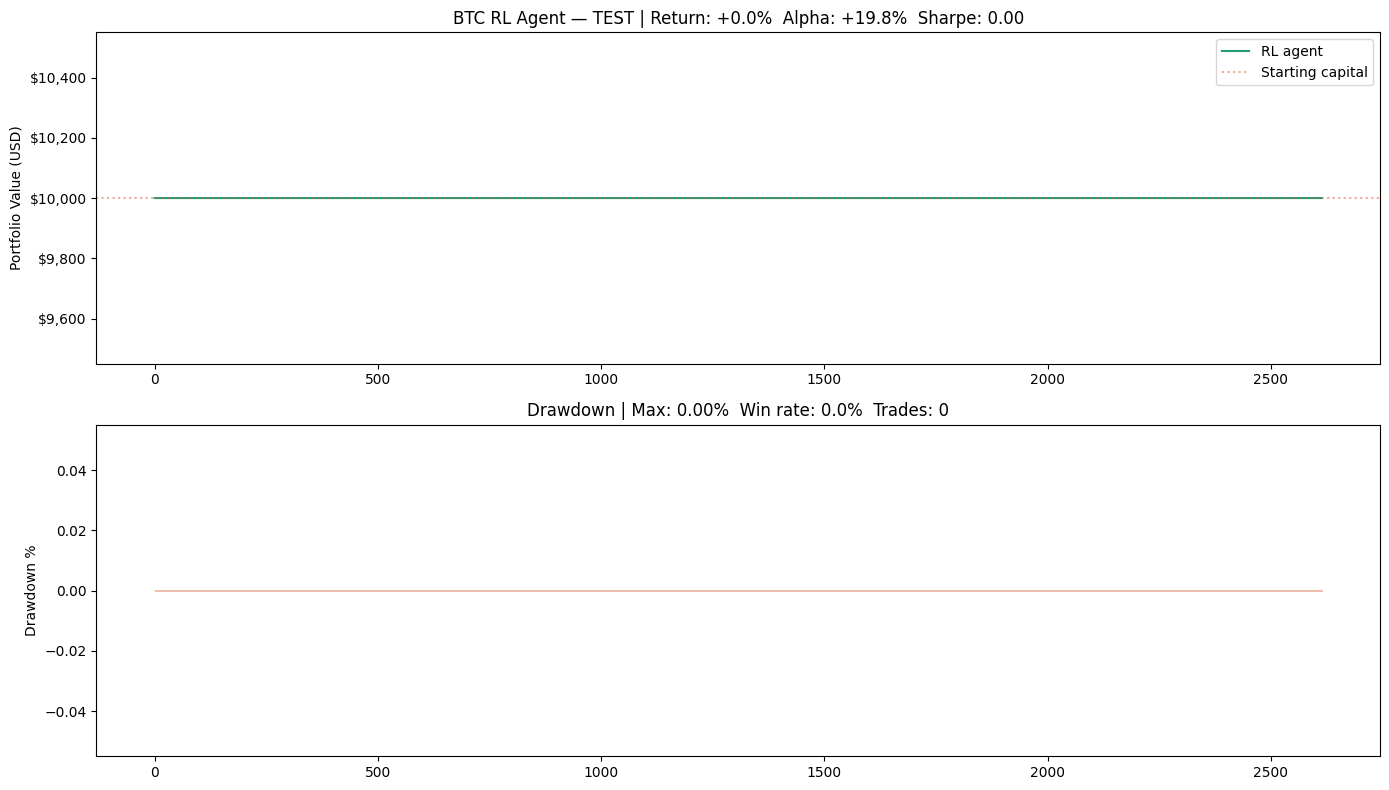

Saved: ./data/rl\btc_rl_test.png


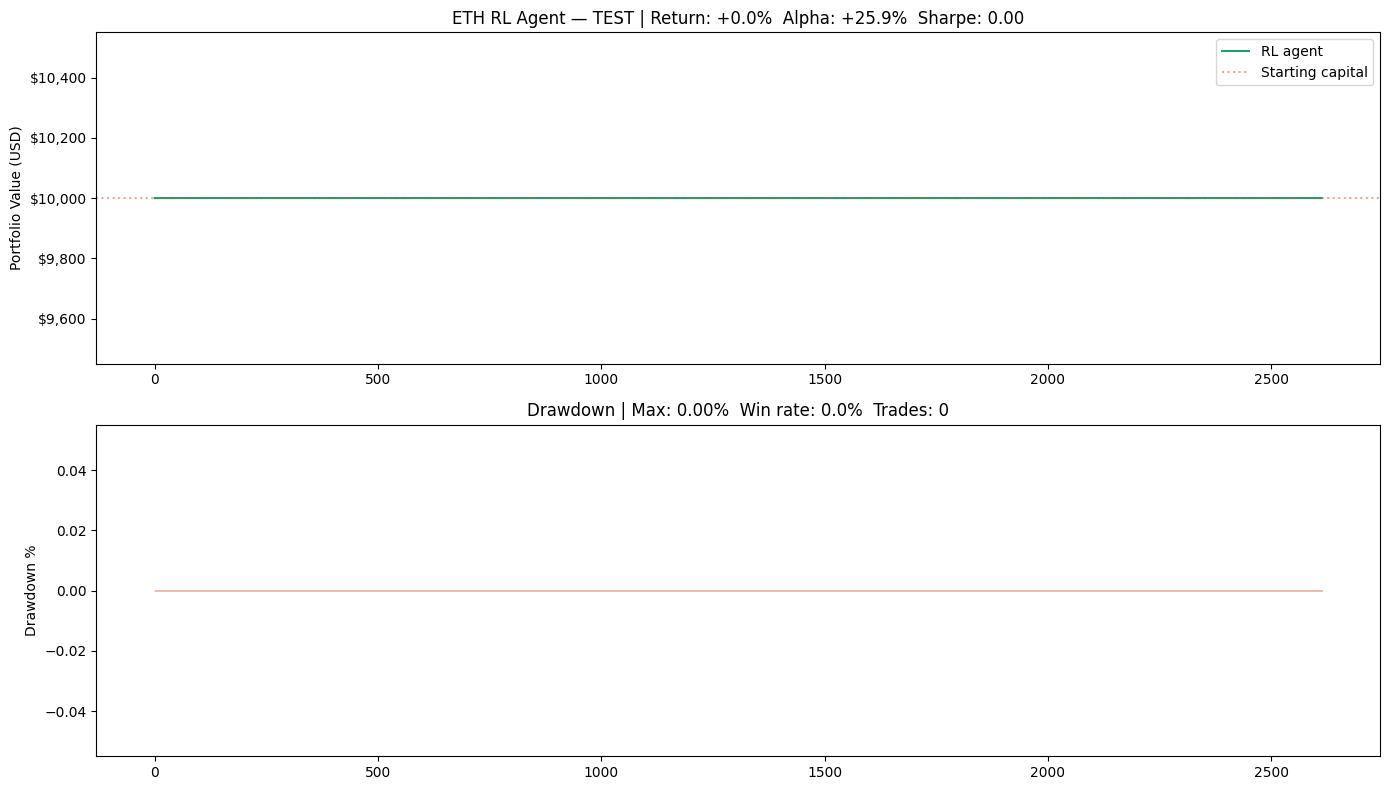

Saved: ./data/rl\eth_rl_test.png


In [13]:
def plot_rl_equity(metrics: dict, name: str, split: str = "test"):
    equity    = metrics["equity"]
    trades    = metrics["trades"]

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

    axes[0].plot(range(len(equity)), equity,
                 color="#1D9E75", linewidth=1.5, label="RL agent")
    axes[0].axhline(10_000, color="#D85A30", linestyle=":",
                    alpha=0.5, label="Starting capital")
    axes[0].set_ylabel("Portfolio Value (USD)")
    axes[0].set_title(
        f"{name} RL Agent — {split.upper()} | "
        f"Return: {metrics['return']:+.1f}%  "
        f"Alpha: {metrics['alpha']:+.1f}%  "
        f"Sharpe: {metrics['sharpe']:.2f}"
    )
    axes[0].legend()
    axes[0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f"${x:,.0f}")
    )

    peak     = np.maximum.accumulate(equity)
    drawdown = (np.array(equity) - peak) / peak * 100
    axes[1].fill_between(range(len(equity)), drawdown, 0,
                         color="#D85A30", alpha=0.4)
    axes[1].set_ylabel("Drawdown %")
    axes[1].set_title(
        f"Drawdown | Max: {metrics['max_dd']:.2f}%  "
        f"Win rate: {metrics['win_rate']:.1f}%  "
        f"Trades: {metrics['n_trades']}"
    )

    plt.tight_layout()
    path = os.path.join(RL_DIR, f"{name.lower()}_rl_{split}.png")
    plt.savefig(path, dpi=120)
    plt.show()
    print(f"Saved: {path}")

plot_rl_equity(btc_test_metrics, "BTC")
plot_rl_equity(eth_test_metrics, "ETH")

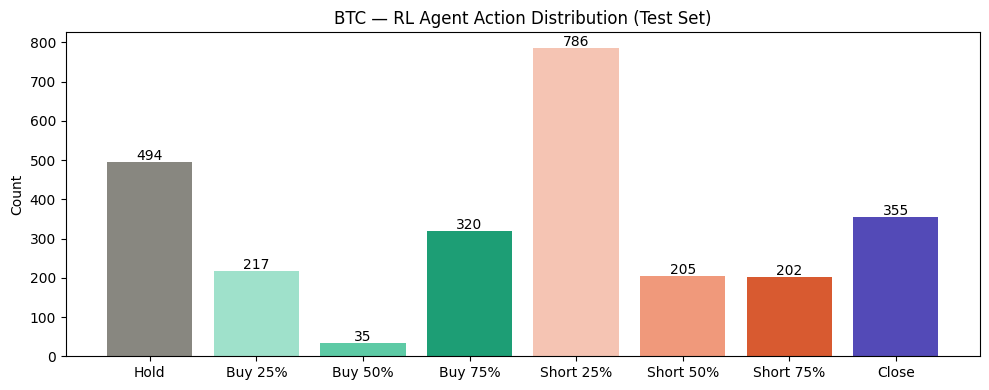

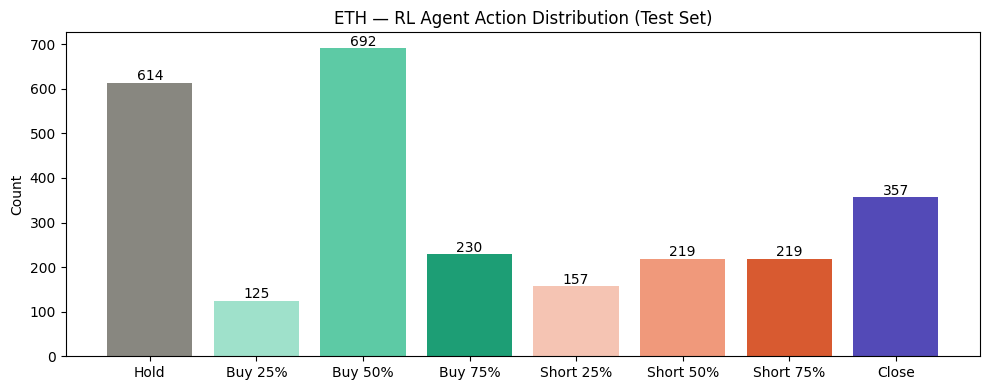

In [14]:
def plot_action_distribution(agent, features, probs,
                              prices, buy_threshold,
                              sell_threshold, stop_loss,
                              take_profit, name: str):
    """
    Shows what actions the agent prefers — are they too passive?
    """
    env = TradingEnv(
        features       = features,
        probs          = probs,
        prices         = prices,
        buy_threshold  = buy_threshold,
        sell_threshold = sell_threshold,
        stop_loss      = stop_loss,
        take_profit    = take_profit,
    )

    obs, _    = env.reset()
    done      = False
    truncated = False
    actions   = []

    while not done and not truncated:
        action, _ = agent.predict(obs, deterministic=True)
        actions.append(int(action))
        obs, _, done, truncated, _ = env.step(int(action))

    action_labels = {
        0: "Hold",
        1: "Buy 25%", 2: "Buy 50%", 3: "Buy 75%",
        4: "Short 25%", 5: "Short 50%", 6: "Short 75%",
        7: "Close"
    }

    counts = pd.Series(actions).value_counts().sort_index()
    colors = ["#888780","#9FE1CB","#5DCAA5","#1D9E75",
              "#F5C4B3","#F0997B","#D85A30","#534AB7"]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars    = ax.bar(
        [action_labels[i] for i in counts.index],
        counts.values,
        color=[colors[i] for i in counts.index]
    )
    ax.set_title(f"{name} — RL Agent Action Distribution (Test Set)")
    ax.set_ylabel("Count")
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                str(count), ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(RL_DIR, f"{name.lower()}_actions.png"), dpi=120)
    plt.show()

plot_action_distribution(
    btc_agent, btc["X_test"], btc_probs["test"],
    btc_prices["test"], BTC_BUY_THRESHOLD,
    BTC_SELL_THRESHOLD, 0.02, 0.04, "BTC"
)
plot_action_distribution(
    eth_agent, eth["X_test"], eth_probs["test"],
    eth_prices["test"], ETH_BUY_THRESHOLD,
    ETH_SELL_THRESHOLD, 0.03, 0.06, "ETH"
)

In [15]:
rl_summary = {
    "btc_val_metrics"  : btc_val_metrics,
    "btc_test_metrics" : btc_test_metrics,
    "eth_val_metrics"  : eth_val_metrics,
    "eth_test_metrics" : eth_test_metrics,
}

summary_path = os.path.join(RL_DIR, "phase5_rl_summary.pkl")
with open(summary_path, "wb") as f:
    pickle.dump(rl_summary, f)

print(f"Summary saved : {summary_path}")
print(f"BTC agent     : {os.path.join(RL_DIR, 'btc_ppo_agent.zip')}")
print(f"ETH agent     : {os.path.join(RL_DIR, 'eth_ppo_agent.zip')}")
print("\nPhase 5 complete.")

Summary saved : ./data/rl\phase5_rl_summary.pkl
BTC agent     : ./data/rl\btc_ppo_agent.zip
ETH agent     : ./data/rl\eth_ppo_agent.zip

Phase 5 complete.
